# Exemplo 12 - Problema de Sequenciamento de Tarefas

# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização

Aqui definimos um problema de **programação inteira mista** usando a linguagem do CMPL.

## 2.1 Objetivo:
Minimizar a multa total por atrasos.

## 2.2 Elementos do modelo:
- **J**: Conjunto de tarefas.
- **Processamento**: Quantidade de horas necessárias para processar as tarefas na máquina.
- **Execução**: Quantidade de horas disponíveis (prazo) para execução das tarefas.
- **Multa**: Valor monetário aplicado para quantidade dias em atraso das tarefas.

## 2.3 Variável de decisão:
- `x[j]`: data de início do processamento da tarefa `j`.
- `y[i,j]`: 1, se a tarefa `i` for processada antes da tarefa `j`; 0, caso contrário.
- `t[j]`: atraso da tarefa `j`.

In [2]:
# Definição do modelo combinado (dados e generalização) em linguagem CMPL (como string)
codigo_cmpl = """

# Modelo de Sequenciamento em Máquina Única (Minimização de Multas)
# Linguagem: CMPL 2.1.0

par:
    # Conjunto de tarefas
    J := set(1..3);

    PROCESSAMENTO[J] := (5, 20, 15);
    EXECUCAO[J] := (25, 22, 35);
    MULTA[J] := (19, 12, 34);
    # Big-M: Soma de todos os tempos de processamento
    M := sum{j in J: PROCESSAMENTO[j]}; # Igual a 40 dias

var:
    x[J] : real[0..];

    t[J] : real[0..];

    y[J,J] : binary;

obj:
    multa_total: sum{j in J: MULTA[j]*t[j]} -> min;

con:
    AtrasoTarefa{j in J: t[j] >= x[j] + PROCESSAMENTO[j] - EXECUCAO[j];}
    Precedencia1{i in J, j in J, i<j: x[i] - x[j] + M*y[i,j] >= PROCESSAMENTO[j];}
    Precedencia2{i in J, j in J, i<j: x[j] - x[i] + M*(1 - y[i,j]) >= PROCESSAMENTO[i];}

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/Exemplo-12_sequenciamento.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [3]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/Exemplo-12_sequenciamento.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              Exemplo-12_sequenciamento.cmpl
Nr. of variables     9
Nr. of constraints   9
Objective name       multa_total
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      170.00              (min!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    C               20.00                0.00                 inf                   -
x[2]                    C                0.00                0.00                 inf                   -
x[3]                    C               25.0

In [4]:
#@title Função para visualização de dados
# ============================================================
# 1. EXTRAÇÃO DOS PARÂMETROS DO MODELO CMPL
# ============================================================

import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def ler_parametro(codigo, nome):
    """
    Extrai um parâmetro do código CMPL.
    """

    padrao = rf"{nome}\s*\[J\]\s*:=\s*\((.*?)\)\s*;"

    resultado = re.search(
        padrao,
        codigo,
        re.IGNORECASE | re.DOTALL
    )

    if not resultado:
        raise ValueError(
            f"Parâmetro '{nome}[J]' não encontrado."
        )

    valores = [
        float(valor.strip())
        for valor in resultado.group(1).split(",")
    ]

    return {
        i + 1: valor
        for i, valor in enumerate(valores)
    }


# ============================================================
# 2. EXTRAÇÃO DOS DADOS DA SOLUÇÃO
# ============================================================

def obter_dados_sequenciamento(modelo, codigo_cmpl):
    """
    Extrai os dados da solução do modelo CMPL.
    """

    processamento = ler_parametro(
        codigo_cmpl,
        "PROCESSAMENTO"
    )

    prazo = ler_parametro(
        codigo_cmpl,
        "EXECUCAO"
    )

    multa = ler_parametro(
        codigo_cmpl,
        "MULTA"
    )

    tarefas = sorted(
        processamento.keys()
    )

    # Início das tarefas
    inicio = {
        tarefa: modelo.x[tarefa].activity
        for tarefa in tarefas
    }

    # Atraso
    atraso = {
        tarefa: modelo.t[tarefa].activity
        for tarefa in tarefas
    }

    # Término
    termino = {
        tarefa: inicio[tarefa] + processamento[tarefa]
        for tarefa in tarefas
    }

    # Custo da multa
    custo = {
        tarefa: multa[tarefa] * atraso[tarefa]
        for tarefa in tarefas
    }

    # Ordem de execução
    ordem = sorted(
        tarefas,
        key=lambda tarefa: inicio[tarefa]
    )

    # Função objetivo
    custo_total = modelo.solution.value

    return {
        "tarefas": tarefas,
        "ordem": ordem,
        "processamento": processamento,
        "prazo": prazo,
        "multa": multa,
        "inicio": inicio,
        "termino": termino,
        "atraso": atraso,
        "custo": custo,
        "custo_total": custo_total
    }


# ============================================================
# 3. GRÁFICO DE GANTT
# ============================================================

def grafico_gantt(dados):
    """
    Gera somente o gráfico de Gantt.
    """

    ordem = dados["ordem"]
    processamento = dados["processamento"]
    prazo = dados["prazo"]
    inicio = dados["inicio"]
    termino = dados["termino"]
    atraso = dados["atraso"]
    custo_total = dados["custo_total"]

    fig, ax = plt.subplots(
        figsize=(13, 5)
    )

    # --------------------------------------------------------
    # CORES
    # --------------------------------------------------------

    cor_tarefa = "#20B2AA"   # Azul-turquesa
    cor_atraso = "#E74C3C"   # Vermelho

    # --------------------------------------------------------
    # TAREFAS
    # --------------------------------------------------------

    for posicao, tarefa in enumerate(ordem):

        inicio_tarefa = inicio[tarefa]
        duracao = processamento[tarefa]

        # Barra da tarefa
        ax.barh(
            posicao,
            duracao,
            left=inicio_tarefa,
            height=0.55,
            color=cor_tarefa,
            edgecolor="black",
            linewidth=1.2
        )

        # Nome da tarefa
        ax.text(
            inicio_tarefa + duracao / 2,
            posicao,
            f"Tarefa {tarefa}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold"
        )

        # ----------------------------------------------------
        # PRAZO
        # ----------------------------------------------------

        ax.axvline(
            prazo[tarefa],
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.7
        )

        # ----------------------------------------------------
        # ATRASO
        # ----------------------------------------------------

        if atraso[tarefa] > 0:

            ax.barh(
                posicao,
                atraso[tarefa],
                left=prazo[tarefa],
                height=0.55,
                color=cor_atraso,
                edgecolor="black",
                linewidth=1.2
            )

            ax.text(
                prazo[tarefa] + atraso[tarefa] / 2,
                posicao,
                f"Atraso: {atraso[tarefa]:.0f}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold"
            )

        # ----------------------------------------------------
        # INÍCIO E TÉRMINO
        # ----------------------------------------------------

        ax.text(
            inicio_tarefa,
            posicao - 0.35,
            f"{inicio_tarefa:.0f}",
            ha="center",
            va="top",
            fontsize=9
        )

        ax.text(
            termino[tarefa],
            posicao - 0.35,
            f"{termino[tarefa]:.0f}",
            ha="center",
            va="top",
            fontsize=9
        )

    # ========================================================
    # CONFIGURAÇÕES
    # ========================================================

    ax.set_yticks(
        range(len(ordem))
    )

    ax.set_yticklabels(
        [f"Tarefa {tarefa}" for tarefa in ordem]
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Tempo",
        fontsize=11
    )

    ax.set_ylabel(
        "Sequência de execução",
        fontsize=11
    )

    ax.set_title(
        f"Sequenciamento Ótimo das Tarefas\n"
        f"Valor da função objetivo = {custo_total:.0f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.5
    )

    tempo_maximo = max(
        max(termino.values()),
        max(prazo.values())
    )

    ax.set_xlim(
        0,
        tempo_maximo + 5
    )

    # Legenda
    legenda = [
        Patch(
            facecolor=cor_tarefa,
            edgecolor="black",
            label="Processamento"
        ),
        Patch(
            facecolor=cor_atraso,
            edgecolor="black",
            label="Atraso"
        )
    ]

    ax.legend(
        handles=legenda,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. GRÁFICO DE MULTAS
# ============================================================

def grafico_multas(dados):
    """
    Gera somente o gráfico de multas.
    """

    tarefas = dados["tarefas"]
    custo = dados["custo"]
    custo_total = dados["custo_total"]

    valores = [
        custo[tarefa]
        for tarefa in tarefas
    ]

    # Verde = sem multa
    # Vermelho = com multa
    cores = [
        "#2ECC71"
        if valor == 0
        else "#E74C3C"
        for valor in valores
    ]

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    barras = ax.bar(
        [f"Tarefa {tarefa}" for tarefa in tarefas],
        valores,
        color=cores,
        edgecolor="black"
    )

    maior_valor = max(
        valores
    ) if valores else 1

    # Valores nas barras
    for barra, valor in zip(
        barras,
        valores
    ):

        ax.text(
            barra.get_x()
            + barra.get_width() / 2,
            valor + maior_valor * 0.03,
            f"{valor:.0f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_xlabel(
        "Tarefas",
        fontsize=11
    )

    ax.set_ylabel(
        "Multa",
        fontsize=11
    )

    ax.set_title(
        f"Multa por Tarefa\n"
        f"Multa total = {custo_total:.0f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

In [5]:
dados = obter_dados_sequenciamento(
    modelo,
    codigo_cmpl
)

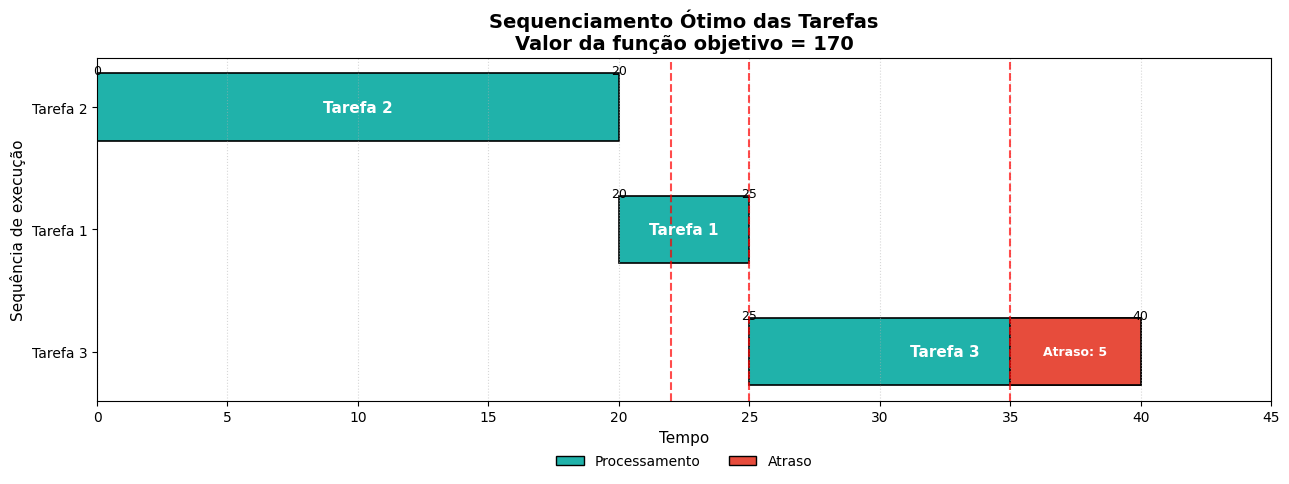

In [6]:
grafico_gantt(dados)

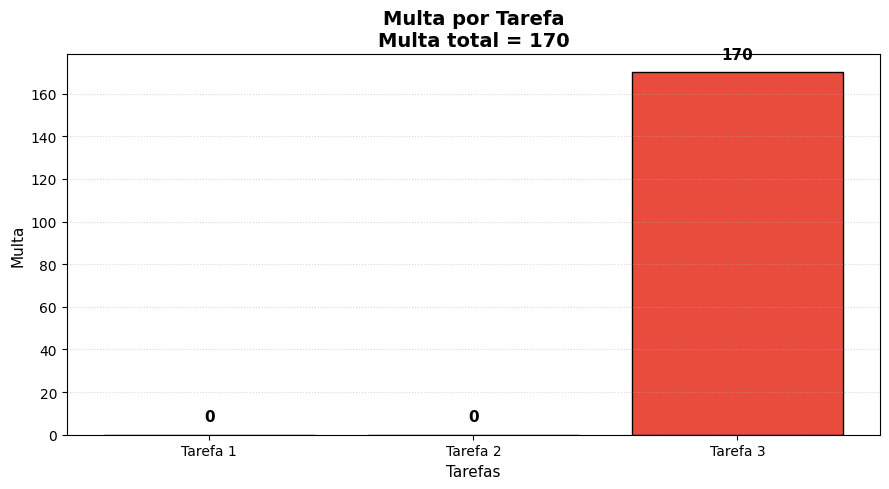

In [7]:
grafico_multas(dados)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3